In [1]:
import numpy as np
import matplotlib.pyplot as plt

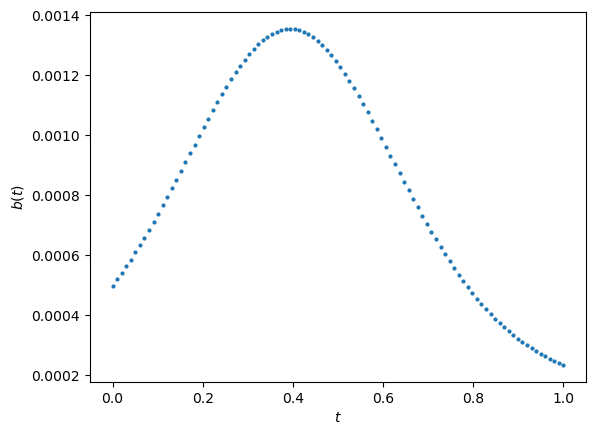

In [2]:
m = 100
n = 15

t = np.linspace(0, 1, m)

A = np.zeros((m,n))
for j in range(n):
    A[:,j] = t**j

b = np.exp(np.sin(4*t))

b = b/2006.787453080206; # chosen so x[14] = 1

plt.plot(t, b,'o',markersize = 2)
plt.xlabel('$t$')
plt.ylabel("$b(t)$")
plt.show()

In [3]:
# "exact solution"
x_lstsq, res, rank, s_vals = np.linalg.lstsq(A, b)

print(x_lstsq[14])

1.0000000926395114


In [4]:
# solution using normal equations and matrix inverse
ATA = A.T @ A
c = A.T @ b
x_normal = np.linalg.inv(ATA) @ c

print(x_normal[14])

0.5410620636218504


In [5]:
# solution using normal equations and np.linalg.solve
ATA = A.T @ A
c = A.T @ b
x_normal_2 = np.linalg.solve(ATA, c) 

print(x_normal_2[14])

0.5409332976351735


In [6]:
# solution using QR factorization and np.linalg.solve
Q, R = np.linalg.qr(A)
x_qr = np.linalg.solve(R, Q.T @ b)

print(x_qr[14])

1.0000000926361714


In [7]:
print("max residual using normal equations with inverse:", max(abs(A@x_normal - b)))
print("max residual using normal equations with np.linalg.solve:", max(abs(A@x_normal_2 - b)))
print("max residual using np.linalg.lstsq:",max(abs(A@x_lstsq - b)))
print("max residual using QR factors:",max(abs(A@x_qr - b)))

max residual using normal equations with inverse: 0.0007245243441407733
max residual using normal equations with np.linalg.solve: 1.2498763499906636e-07
max residual using np.linalg.lstsq: 9.012772807909762e-09
max residual using QR factors: 9.012772794465655e-09


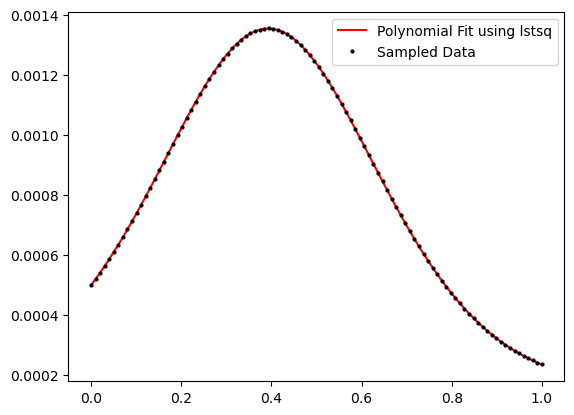

In [8]:
plt.plot(t, A@x_lstsq, 'r-', zorder = 0)
plt.plot(t, b,'ko',markersize = 2, zorder = 1)
plt.legend(['Polynomial Fit using lstsq', 'Sampled Data'])
plt.show()

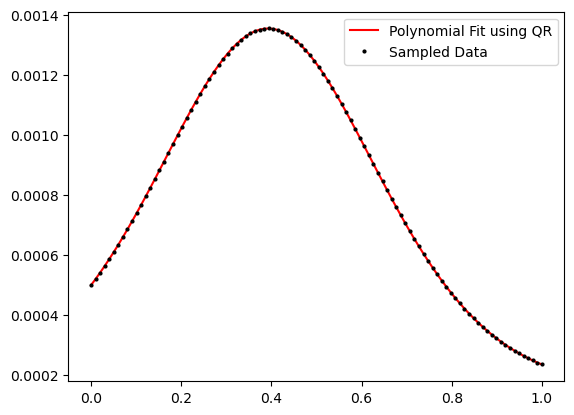

In [9]:
plt.plot(t, A@x_qr, 'r-', zorder = 0)
plt.plot(t, b,'ko',markersize = 2, zorder = 1)
plt.legend(['Polynomial Fit using QR', 'Sampled Data'])
plt.show()

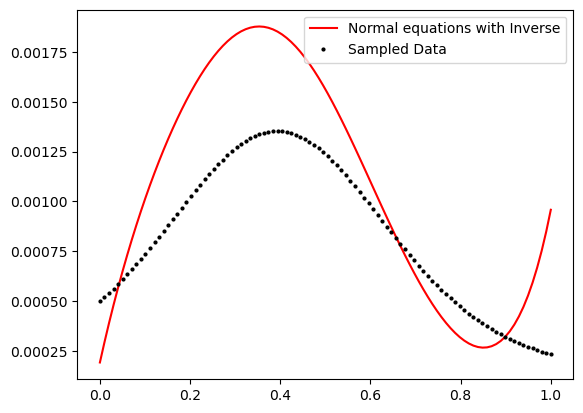

In [10]:
plt.plot(t, A@x_normal, 'r-', zorder = 0)
plt.plot(t, b,'ko',markersize = 2, zorder = 1)
plt.legend(['Normal equations with Inverse', 'Sampled Data'],loc='best')
plt.show()

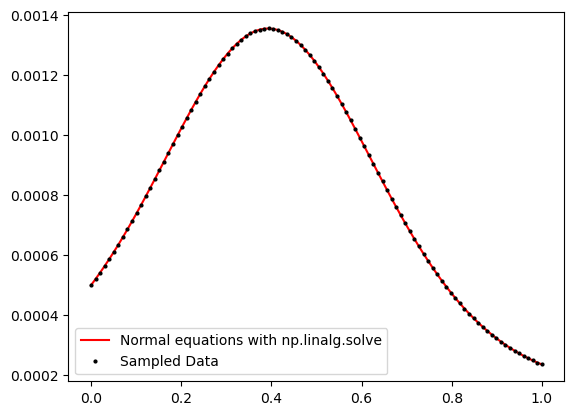

In [11]:
plt.plot(t, A@x_normal_2, 'r-', zorder = 0)
plt.plot(t, b,'ko',markersize = 2, zorder = 1)
plt.legend(['Normal equations with np.linalg.solve', 'Sampled Data'],loc='best')
plt.show()

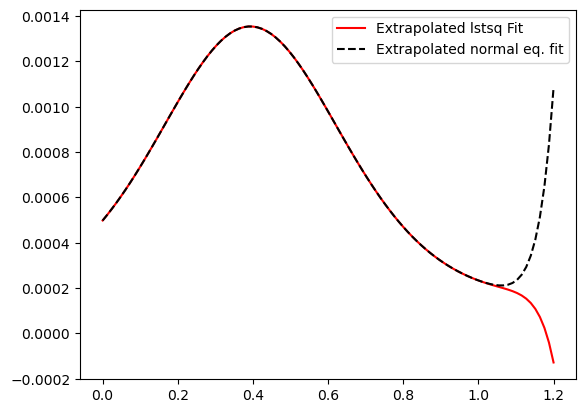

In [12]:
t_extended = np.linspace(0, 1.2, m)

A_ext = np.zeros((m,n))
for j in range(n):
    A_ext[:,j] = t_extended**j

b_ex = np.exp(np.sin(4*t_extended))

b_ex = b_ex/2006.787453080206


plt.plot(t_extended, A_ext@x_lstsq, 'r-', zorder = 0)
plt.plot(t_extended, A_ext@x_normal_2,'k--', zorder = 1)
plt.legend(['Extrapolated lstsq Fit', 'Extrapolated normal eq. fit'])
plt.show()

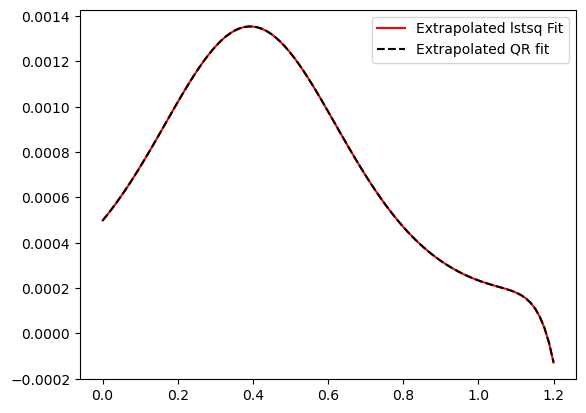

In [13]:
plt.plot(t_extended, A_ext@x_lstsq, 'r-', zorder = 0)
plt.plot(t_extended, A_ext@x_qr,'k--', zorder = 1)
plt.legend(['Extrapolated lstsq Fit', 'Extrapolated QR fit'])
plt.show()